In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
TOTAL_POINTS = 500_000

In [30]:
# Generate random points in [-1, 1] x [-1, 1]
x = np.random.uniform(-1, 1, TOTAL_POINTS)
y = np.random.uniform(-1, 1, TOTAL_POINTS)

# Check which points fall inside the unit circle
inside = x**2 + y**2 <= 1

# Running count of points inside the circle
cumulative_inside = np.cumsum(inside)
point_indices = np.arange(1, TOTAL_POINTS + 1)

# Running pi approximation: pi ≈ 4 * (points inside circle / total points)
running_pi = 4 * cumulative_inside / point_indices

# Error analysis
error = np.abs(running_pi - np.pi)

error_percentage = (error / np.pi) * 100


print(f"Final estimate: {running_pi[-1]:.6f} ({TOTAL_POINTS} points)")
print(f"Final error: {error[-1]:.2e}")
print(f"Final error percentage: {error_percentage[-1]:.4f}%")

Final estimate: 3.143064 (500000 points)
Final error: 1.47e-03
Final error percentage: 0.0468%


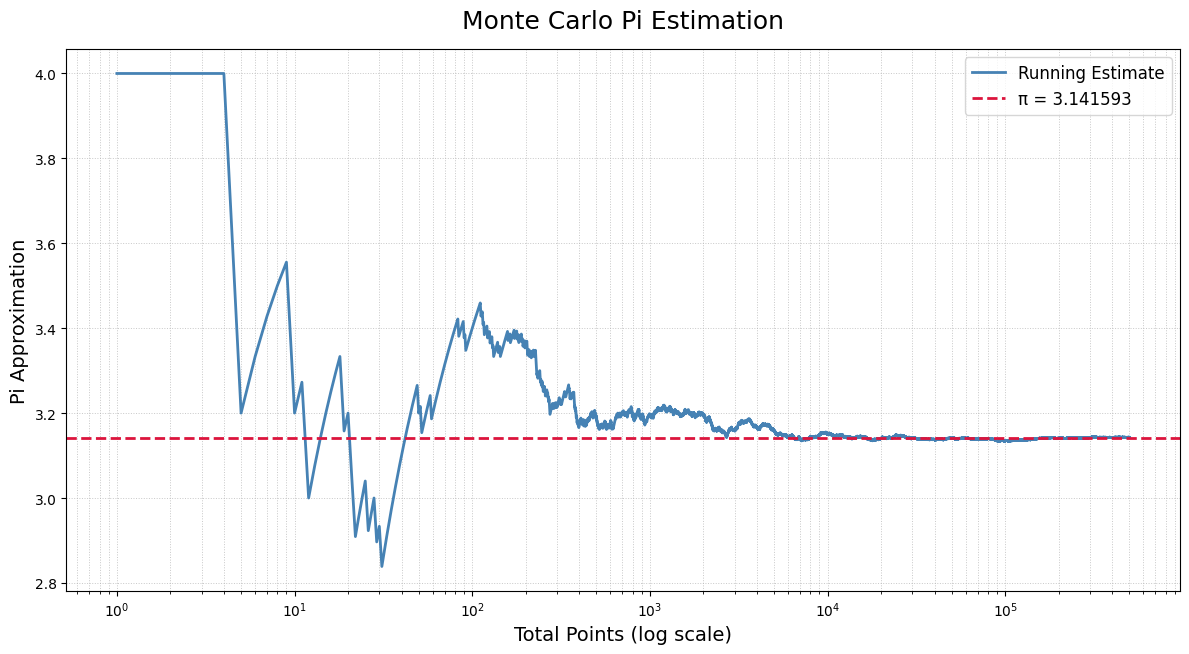

In [39]:
plt.figure(figsize=(12, 7))
plt.plot(point_indices, running_pi, linewidth=2, color="steelblue", label="Running Estimate")
plt.axhline(y=np.pi, color="crimson", linestyle="--", linewidth=2, label=f"π = {np.pi:.6f}")
plt.xscale("log")
plt.xlabel("Total Points (log scale)", fontsize=14)
plt.ylabel("Pi Approximation", fontsize=14)
plt.title("Monte Carlo Pi Estimation", fontsize=18, pad=15)
plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [34]:
# Compute grid size (as close to square as possible)
grid_n = int(np.sqrt(TOTAL_POINTS))
grid_x = np.linspace(-1 + 1/grid_n, 1 - 1/grid_n, grid_n)
grid_y = np.linspace(-1 + 1/grid_n, 1 - 1/grid_n, grid_n)

# Create meshgrid and flatten
xx, yy = np.meshgrid(grid_x, grid_y)
xu = xx.ravel()
yu = yy.ravel()

# Check which points fall inside the unit circle
inside_u = xu**2 + yu**2 <= 1
cumulative_inside_u = np.cumsum(inside_u)
point_indices_u = np.arange(1, len(xu) + 1)
running_pi_u = 4 * cumulative_inside_u / point_indices_u

error_u = np.abs(running_pi_u - np.pi)
error_percentage_u = (error_u / np.pi) * 100

print(f"Final estimate (uniform): {running_pi_u[-1]:.6f} ({len(xu)} points)")
print(f"Final error (uniform): {error_u[-1]:.2e}")
print(f"Final error percentage (uniform): {error_percentage_u[-1]:.4f}%")

Final estimate (uniform): 3.141565 (499849 points)
Final error (uniform): 2.79e-05
Final error percentage (uniform): 0.0009%


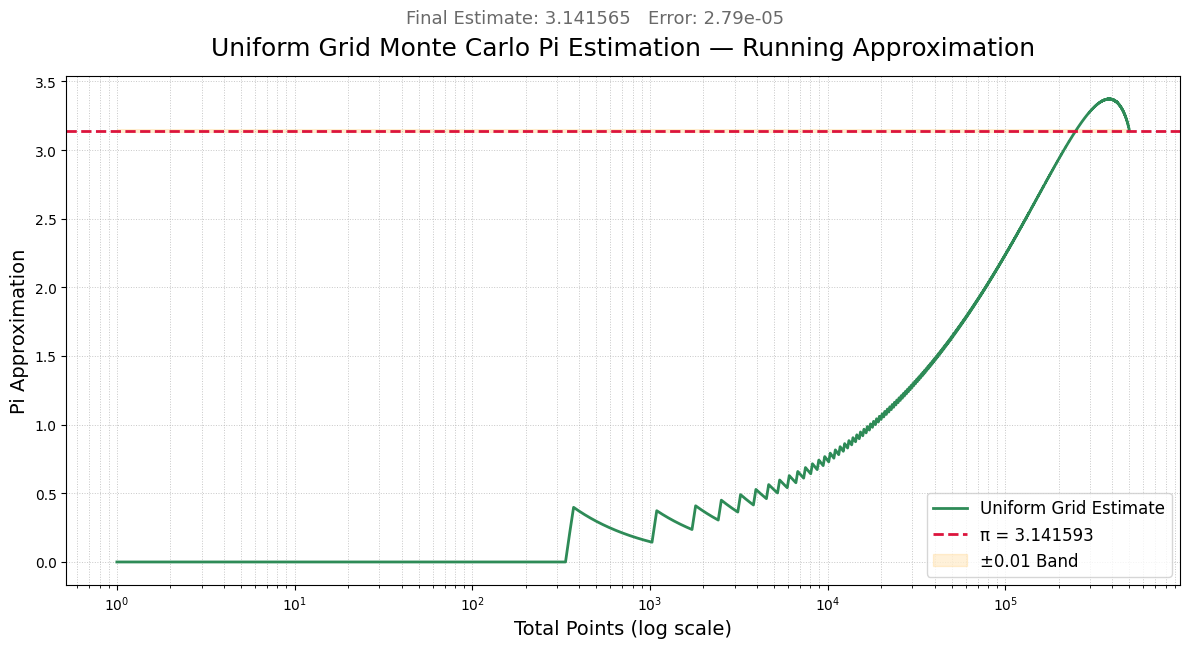

In [36]:
plt.figure(figsize=(12, 7))
plt.plot(point_indices_u, running_pi_u, linewidth=2, color="seagreen", label="Uniform Grid Estimate")
plt.axhline(y=np.pi, color="crimson", linestyle="--", linewidth=2, label=f"π = {np.pi:.6f}")
plt.fill_between(point_indices_u, np.pi-0.01, np.pi+0.01, color="orange", alpha=0.15, label="±0.01 Band")
plt.xscale("log")
plt.xlabel("Total Points (log scale)", fontsize=14)
plt.ylabel("Pi Approximation", fontsize=14)
plt.title("Uniform Grid Monte Carlo Pi Estimation — Running Approximation", fontsize=18, pad=15)
final_est_u = running_pi_u[-1]
plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [41]:
# Uniform grid method
DX = 2 / (TOTAL_POINTS ** 0.5)
DY = 2 / (TOTAL_POINTS ** 0.5)

uniform_points_in_circle = []
uniform_running_pi = []

for n in range(TOTAL_POINTS):
    row = n // int(2 / DY)
    col = n % int(2 / DX)
    x = -1 + (col * DX + DX / 2)
    y = 1 - (row * DY + DY / 2)
    inside = x**2 + y**2 <= 1
    if n == 0:
        uniform_points_in_circle.append(int(inside))
    else:
        uniform_points_in_circle.append(uniform_points_in_circle[-1] + int(inside))
    uniform_running_pi.append(4 * uniform_points_in_circle[-1] / (n + 1))

uniform_running_pi = np.array(uniform_running_pi)

error_uniform = np.abs(uniform_running_pi - np.pi)
error_percentage_uniform = (error_uniform / np.pi) * 100

print(f"Final estimate (uniform, raylib logic): {uniform_running_pi[-1]:.6f} ({TOTAL_POINTS} points)")
print(f"Final error (uniform, raylib logic): {error_uniform[-1]:.2e}")
print(f"Final error percentage (uniform, raylib logic): {error_percentage_uniform[-1]:.4f}%")

Final estimate (uniform, raylib logic): 3.141504 (500000 points)
Final error (uniform, raylib logic): 8.87e-05
Final error percentage (uniform, raylib logic): 0.0028%


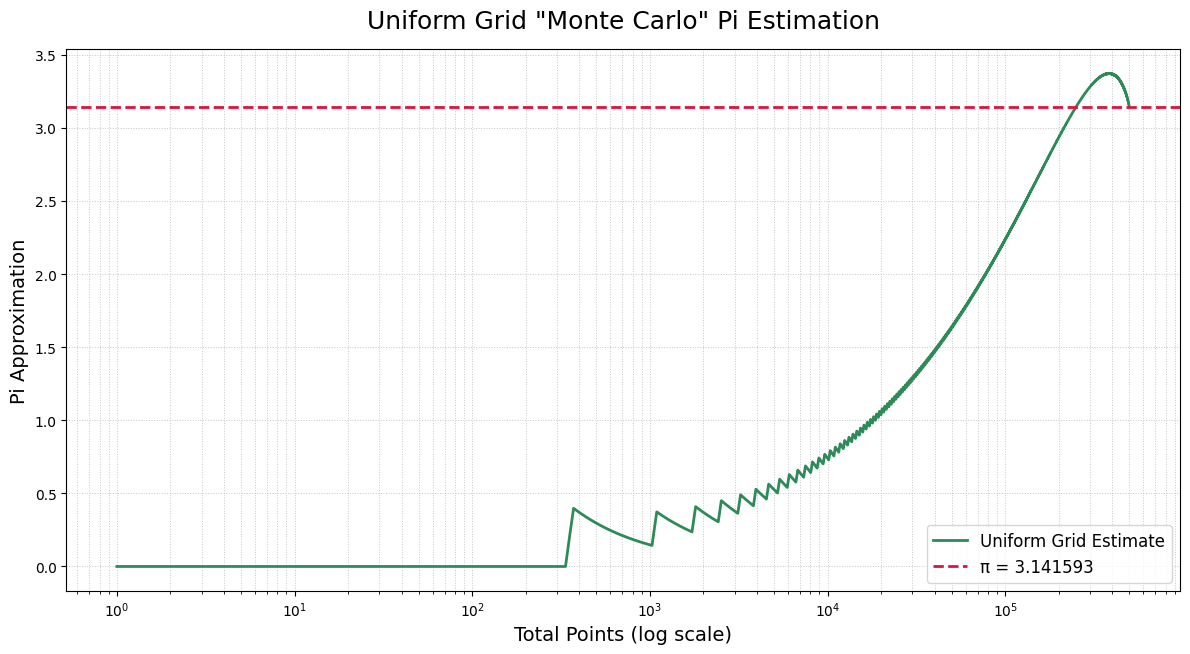

In [46]:
plt.figure(figsize=(12, 7))
plt.plot(point_indices_u, running_pi_u, linewidth=2, color="seagreen", label="Uniform Grid Estimate")
plt.axhline(y=np.pi, color="crimson", linestyle="--", linewidth=2, label=f"π = {np.pi:.6f}")
plt.xscale("log")
plt.xlabel("Total Points (log scale)", fontsize=14)
plt.ylabel("Pi Approximation", fontsize=14)
plt.title("Uniform Grid \"Monte Carlo\" Pi Estimation", fontsize=18, pad=15)
plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()